# 🤖 Étape 5 : Modélisation & Prédiction — Baseline Models

Ce notebook implémente la phase de modélisation supervisée sur le dataset **corrigé** `MASTER_DATASET_ML_READY_FIXED.csv`.

### 🎯 Objectifs
1. **Chargement & Split temporel** (Walk-Forward / Expanding Window) — pas de leakage
2. **Baselines** : Logistic Regression, Random Forest, XGBoost, LightGBM, SVM
3. **Deep Learning** : GRU, LSTM, BiLSTM, Chronos, Chronos-Multivariate
4. **Validation rigoureuse** : TimeSeriesSplit + métriques adaptées au déséquilibre (F1, MCC, AUC)
5. **Feature Importance** & analyse par ticker / régime
5. **Sélection du meilleur modèle** pour le backtesting (Étape 6)

## 📦 Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef,
    make_scorer
)

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Chronos
try:
    from chronos import ChronosPipeline
    CHRONOS_AVAILABLE = True
    print("✅ Chronos disponible")
except ImportError:
    CHRONOS_AVAILABLE = False
    print("⚠️ Chronos non installé : pip install chronos-forecasting")

# Utils
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("✅ Imports OK")

✅ Chronos disponible
✅ Imports OK


## 🔒 Reproductibilité — Seeds Fixes

In [2]:
# Seed global pour reproductibilité totale
import random
import os

SEED = 42

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Python hash seed
os.environ['PYTHONHASHSEED'] = str(SEED)

# DataLoader worker seed
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print(f"🔒 Reproductibilité activée (SEED={SEED})")

🔒 Reproductibilité activée (SEED=42)


## 📥 Chargement du Dataset ML-Ready (CORRIGÉ)

In [3]:
PATH = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\MASTER_DATASET_FULL_FEATURES_v2.csv"
df = pd.read_csv(PATH, parse_dates=['Date'])

# Tri chronologique strict (le plus ancien → le plus récent)
df = df.sort_values(['Date', 'Ticker']).reset_index(drop=True)

# Filtrer les 5 tickers alpha
tickers_alpha = ['JPM', 'AMZN', 'TSLA', 'MSFT', 'UNH']
df = df[df['Ticker'].isin(tickers_alpha)].copy()

print(f"Shape: {df.shape}")
print(f"Période: {df['Date'].min()} → {df['Date'].max()}")
print(f"Tickers: {sorted(df['Ticker'].unique())}")
print(f"\nTarget distribution:")
print(df['Target'].value_counts().sort_index())
print(f"\nFeatures: {[c for c in df.columns if c not in ['Date','Ticker','Target']]}")

Shape: (1990, 54)
Période: 2023-03-01 00:00:00 → 2026-07-10 00:00:00
Tickers: ['AMZN', 'JPM', 'MSFT', 'TSLA', 'UNH']

Target distribution:
Target
0     984
1    1006
Name: count, dtype: int64

Features: ['Volume', 'StockChange', 'Daily_Volatility', 'FinBERT_Positive', 'FinBERT_Negative', 'FinBERT_Neutral', 'Volume_Messages', 'Score_Net', 'Bullishness_Index', 'Polarite_Index', 'Score_Net_Lag1', 'Score_Net_Lag2', 'Score_Net_Lag3', 'Score_Net_Lag5', 'Volume_Messages_Lag1', 'Volume_Messages_Lag2', 'Volume_Messages_Lag3', 'Volume_Messages_Lag5', 'Polarite_Index_Lag1', 'Polarite_Index_Lag2', 'Polarite_Index_Lag3', 'Polarite_Index_Lag5', 'Bullishness_Index_Lag1', 'Bullishness_Index_Lag2', 'Bullishness_Index_Lag3', 'Bullishness_Index_Lag5', 'Volatility_20d', 'Volume_Avg20d', 'Sentiment_x_Volatility', 'Sentiment_x_Volume', 'Sentiment_Strength', 'Sentiment_Momentum_3d', 'Sentiment_Acceleration', 'Vol_Regime', 'Return_Momentum_5d', 'Volume_Trend', 'Return_1d', 'Return_5d', 'RSI_14', 'BB_Middle', 

## 🎯 Définition Features / Target

- **Target** : `Target` (1 = hausse intraday, 0 = baisse/stable) — **déjà encodé 0/1**
- **Features** : toutes les colonnes sauf `Date`, `Ticker`, `Target`, `StockChange`
- **Note** : `StockChange` est la version continue du target — on la **retire** pour éviter leakage

In [4]:
drop_cols = ['Date', 'Ticker', 'Target', 'StockChange']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df['Target'].copy()

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"\nClass balance: {y.mean():.2%} positifs (1), {(1-y.mean()):.2%} négatifs (0)")

# Vérif NaN
print(f"\nNaN dans X: {X.isnull().sum().sum()}")

Features (50): ['Volume', 'Daily_Volatility', 'FinBERT_Positive', 'FinBERT_Negative', 'FinBERT_Neutral', 'Volume_Messages', 'Score_Net', 'Bullishness_Index', 'Polarite_Index', 'Score_Net_Lag1', 'Score_Net_Lag2', 'Score_Net_Lag3', 'Score_Net_Lag5', 'Volume_Messages_Lag1', 'Volume_Messages_Lag2', 'Volume_Messages_Lag3', 'Volume_Messages_Lag5', 'Polarite_Index_Lag1', 'Polarite_Index_Lag2', 'Polarite_Index_Lag3', 'Polarite_Index_Lag5', 'Bullishness_Index_Lag1', 'Bullishness_Index_Lag2', 'Bullishness_Index_Lag3', 'Bullishness_Index_Lag5', 'Volatility_20d', 'Volume_Avg20d', 'Sentiment_x_Volatility', 'Sentiment_x_Volume', 'Sentiment_Strength', 'Sentiment_Momentum_3d', 'Sentiment_Acceleration', 'Vol_Regime', 'Return_Momentum_5d', 'Volume_Trend', 'Return_1d', 'Return_5d', 'RSI_14', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'BB_Position', 'Target_H1', 'Target_H3', 'Target_H5', 'Target_H10', 'Target_Asym', 'Target_Return', 'Target_Volatility']

Class balance: 50.55% positifs (1), 49.45% néga

## ✂️ Split Temporel — Walk-Forward Validation

On utilise **TimeSeriesSplit** (expanding window) pour respecter l'ordre temporel.
Chaque fold : train = passé, test = futur immédiat.

🔑 **Pas de shuffle**, **pas de stratification** — l'ordre chronologique est la règle.

In [5]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=int(len(df) * 0.15), gap=10)

print("Folds (indices):")
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    train_dates = df.iloc[train_idx]['Date']
    test_dates = df.iloc[test_idx]['Date']
    print(f"  Fold {i+1}: Train {train_dates.min().date()} → {train_dates.max().date()} | Test {test_dates.min().date()} → {test_dates.max().date()} | n_train={len(train_idx)}, n_test={len(test_idx)}")

Folds (indices):
  Fold 1: Train 2023-03-01 → 2024-07-19 | Test 2024-08-01 → 2025-05-12 | n_train=490, n_test=298
  Fold 2: Train 2023-03-01 → 2025-05-02 | Test 2025-05-13 → 2025-09-11 | n_train=788, n_test=298
  Fold 3: Train 2023-03-01 → 2025-09-09 | Test 2025-09-11 → 2025-12-16 | n_train=1086, n_test=298
  Fold 4: Train 2023-03-01 → 2025-12-12 | Test 2025-12-16 → 2026-03-25 | n_train=1384, n_test=298
  Fold 5: Train 2023-03-01 → 2026-03-23 | Test 2026-03-25 → 2026-07-10 | n_train=1682, n_test=298


## 📊 Métriques d'Évaluation

Dataset déséquilibré (~55% / 45%) → **Accuracy insuffisante**.
On privilégie :
- **F1-Score** (moyenne harmonique Precision/Recall)
- **MCC** (Matthews Correlation Coefficient) — robuste au déséquilibre
- **AUC-ROC** — capacité de séparation des classes
- **Precision / Recall** par classe

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef

def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    """Retourne un dict de métriques."""
    metrics = {
        'model': model_name,
        'precision_0': precision_score(y_true, y_pred, pos_label=0),
        'recall_0': recall_score(y_true, y_pred, pos_label=0),
        'f1_0': f1_score(y_true, y_pred, pos_label=0),
        'precision_1': precision_score(y_true, y_pred, pos_label=1),
        'recall_1': recall_score(y_true, y_pred, pos_label=1),
        'f1_1': f1_score(y_true, y_pred, pos_label=1),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'mcc': matthews_corrcoef(y_true, y_pred),
    }
    if y_proba is not None:
        metrics['auc_roc'] = roc_auc_score(y_true, y_proba)
    return metrics

print("✅ Fonction d'évaluation prête")

✅ Fonction d'évaluation prête


## 🔵 Baseline 1 : Logistic Regression (avec StandardScaler)
Modèle linéaire de référence, interprétable, sensible à la mise à l'échelle.

In [7]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lr_results = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    lr_pipe.fit(X_train, y_train)
    y_pred = lr_pipe.predict(X_test)
    y_proba = lr_pipe.predict_proba(X_test)[:, 1]
    
    metrics = evaluate_model(y_test, y_pred, y_proba, f"LogisticReg_Fold{fold+1}")
    lr_results.append(metrics)
    print(f"Fold {fold+1}: F1_macro={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")

lr_df = pd.DataFrame(lr_results)
print(f"\n📊 Logistic Regression — Moyenne ± Std:")
print(f"  F1_macro: {lr_df['f1_macro'].mean():.4f} ± {lr_df['f1_macro'].std():.4f}")
print(f"  MCC:      {lr_df['mcc'].mean():.4f} ± {lr_df['mcc'].std():.4f}")
print(f"  AUC:      {lr_df['auc_roc'].mean():.4f} ± {lr_df['auc_roc'].std():.4f}")

Fold 1: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 2: F1_macro=0.9966 | MCC=0.9933 | AUC=1.0000
Fold 3: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 4: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 5: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000

📊 Logistic Regression — Moyenne ± Std:
  F1_macro: 0.9993 ± 0.0015
  MCC:      0.9987 ± 0.0030
  AUC:      1.0000 ± 0.0000


## 🌲 Baseline 2 : Random Forest
Robuste à la colinéarité, capture non-linéarités, donne feature importance nativement.

In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_results = []
rf_importances = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]
    
    metrics = evaluate_model(y_test, y_pred, y_proba, f"RandomForest_Fold{fold+1}")
    rf_results.append(metrics)
    rf_importances.append(pd.Series(rf.feature_importances_, index=feature_cols))
    print(f"Fold {fold+1}: F1_macro={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")

rf_df = pd.DataFrame(rf_results)
print(f"\n📊 Random Forest — Moyenne ± Std:")
print(f"  F1_macro: {rf_df['f1_macro'].mean():.4f} ± {rf_df['f1_macro'].std():.4f}")
print(f"  MCC:      {rf_df['mcc'].mean():.4f} ± {rf_df['mcc'].std():.4f}")
print(f"  AUC:      {rf_df['auc_roc'].mean():.4f} ± {rf_df['auc_roc'].std():.4f}")

# Feature importance moyenne
imp_mean = pd.concat(rf_importances, axis=1).mean(axis=1).sort_values(ascending=False)
print(f"\n🔝 Top 10 Features (RF):")
print(imp_mean.head(10))

Fold 1: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 2: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 3: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 4: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 5: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000

📊 Random Forest — Moyenne ± Std:
  F1_macro: 1.0000 ± 0.0000
  MCC:      1.0000 ± 0.0000
  AUC:      1.0000 ± 0.0000

🔝 Top 10 Features (RF):
Target_Return         0.259281
Return_1d             0.244105
Target_Asym           0.215931
BB_Position           0.169597
RSI_14                0.050476
Return_5d             0.014081
Return_Momentum_5d    0.013776
BB_Middle             0.003519
Target_Volatility     0.002238
Daily_Volatility      0.001917
dtype: float64


## 🚀 Baseline 3 : XGBoost
Gradient boosting performant, gère bien les features corrélées.

In [9]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.0,  # ajusté si besoin
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_results = []
xgb_importances = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    xgb_clf.fit(X_train, y_train)
    y_pred = xgb_clf.predict(X_test)
    y_proba = xgb_clf.predict_proba(X_test)[:, 1]
    
    metrics = evaluate_model(y_test, y_pred, y_proba, f"XGBoost_Fold{fold+1}")
    xgb_results.append(metrics)
    xgb_importances.append(pd.Series(xgb_clf.feature_importances_, index=feature_cols))
    print(f"Fold {fold+1}: F1_macro={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")

xgb_df = pd.DataFrame(xgb_results)
print(f"\n📊 XGBoost — Moyenne ± Std:")
print(f"  F1_macro: {xgb_df['f1_macro'].mean():.4f} ± {xgb_df['f1_macro'].std():.4f}")
print(f"  MCC:      {xgb_df['mcc'].mean():.4f} ± {xgb_df['mcc'].std():.4f}")
print(f"  AUC:      {xgb_df['auc_roc'].mean():.4f} ± {xgb_df['auc_roc'].std():.4f}")

imp_mean = pd.concat(xgb_importances, axis=1).mean(axis=1).sort_values(ascending=False)
print(f"\n🔝 Top 10 Features (XGB):")
print(imp_mean.head(10))

Fold 1: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 2: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 3: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 4: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 5: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000

📊 XGBoost — Moyenne ± Std:
  F1_macro: 1.0000 ± 0.0000
  MCC:      1.0000 ± 0.0000
  AUC:      1.0000 ± 0.0000

🔝 Top 10 Features (XGB):
Target_Return           0.502087
Target_Asym             0.257458
Return_1d               0.239847
Volume_Messages_Lag5    0.000219
RSI_14                  0.000190
Return_Momentum_5d      0.000122
Return_5d               0.000062
Volume_Avg20d           0.000016
Daily_Volatility        0.000000
Volume_Messages         0.000000
dtype: float32


## 🌿 Baseline 4 : LightGBM
Plus rapide que XGBoost, souvent meilleur sur données tabulaires.

In [10]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgb_results = []
lgb_importances = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    lgb_clf.fit(X_train, y_train)
    y_pred = lgb_clf.predict(X_test)
    y_proba = lgb_clf.predict_proba(X_test)[:, 1]
    
    metrics = evaluate_model(y_test, y_pred, y_proba, f"LightGBM_Fold{fold+1}")
    lgb_results.append(metrics)
    lgb_importances.append(pd.Series(lgb_clf.feature_importances_, index=feature_cols))
    print(f"Fold {fold+1}: F1_macro={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")

lgb_df = pd.DataFrame(lgb_results)
print(f"\n📊 LightGBM — Moyenne ± Std:")
print(f"  F1_macro: {lgb_df['f1_macro'].mean():.4f} ± {lgb_df['f1_macro'].std():.4f}")
print(f"  MCC:      {lgb_df['mcc'].mean():.4f} ± {lgb_df['mcc'].std():.4f}")
print(f"  AUC:      {lgb_df['auc_roc'].mean():.4f} ± {lgb_df['auc_roc'].std():.4f}")

imp_mean = pd.concat(lgb_importances, axis=1).mean(axis=1).sort_values(ascending=False)
print(f"\n🔝 Top 10 Features (LGB):")
print(imp_mean.head(10))

Fold 1: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 2: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 3: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 4: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000
Fold 5: F1_macro=1.0000 | MCC=1.0000 | AUC=1.0000

📊 LightGBM — Moyenne ± Std:
  F1_macro: 1.0000 ± 0.0000
  MCC:      1.0000 ± 0.0000
  AUC:      1.0000 ± 0.0000

🔝 Top 10 Features (LGB):
Return_1d         547.2
BB_Position       535.6
BB_Middle         262.0
Target_Return     101.6
Volume             78.4
BB_Upper           73.8
BB_Lower           55.8
Target_Asym        52.0
Volume_Avg20d      48.0
Score_Net_Lag5     46.2
dtype: float64


## ⚙️ Baseline 5 : Support Vector Machine (SVM)
Modèle à marge maximale, efficace en haute dimension, sensible à la mise à l'échelle.

In [11]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        class_weight='balanced',
        probability=True,  # nécessaire pour predict_proba / AUC
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=RANDOM_STATE
    ))
])

svm_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    svm_pipe.fit(X_train, y_train)
    y_pred = svm_pipe.predict(X_test)
    y_proba = svm_pipe.predict_proba(X_test)[:, 1]
    
    metrics = evaluate_model(y_test, y_pred, y_proba, f"SVM_Fold{fold+1}")
    svm_results.append(metrics)
    print(f"Fold {fold+1}: F1_macro={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")

svm_df = pd.DataFrame(svm_results)
print(f"\n📊 SVM — Moyenne ± Std:")
print(f"  F1_macro: {svm_df['f1_macro'].mean():.4f} ± {svm_df['f1_macro'].std():.4f}")
print(f"  MCC:      {svm_df['mcc'].mean():.4f} ± {svm_df['mcc'].std():.4f}")
print(f"  AUC:      {svm_df['auc_roc'].mean():.4f} ± {svm_df['auc_roc'].std():.4f}")

Fold 1: F1_macro=0.9832 | MCC=0.9670 | AUC=0.9994
Fold 2: F1_macro=0.8729 | MCC=0.7685 | AUC=0.9600
Fold 3: F1_macro=0.9328 | MCC=0.8698 | AUC=0.9906
Fold 4: F1_macro=0.9933 | MCC=0.9866 | AUC=0.9996
Fold 5: F1_macro=0.9866 | MCC=0.9735 | AUC=0.9998

📊 SVM — Moyenne ± Std:
  F1_macro: 0.9538 ± 0.0512
  MCC:      0.9131 ± 0.0932
  AUC:      0.9899 ± 0.0172


## 🧠 Imports pour Deep Learning & Chronos

In [12]:
# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Chronos
try:
    from chronos import ChronosPipeline
    CHRONOS_AVAILABLE = True
    print("✅ Chronos disponible")
except ImportError:
    CHRONOS_AVAILABLE = False
    print("⚠️ Chronos non installé : pip install chronos-forecasting")

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Device: {DEVICE}")

✅ Chronos disponible
🖥️ Device: cuda


## 🔧 Préparation des Séquences pour Deep Learning

Création de fenêtres glissantes (sliding windows) pour transformer les données tabulaires en séquences temporelles.

In [13]:
def create_sequences(X, y, seq_len=20):
    """Transforme X, y en séquences de longueur seq_len."""
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 20  # 20 jours d'historique

# Préparation par ticker (important : pas de mélange entre tickers)
X_seq_list, y_seq_list = [], []

for ticker in sorted(df['Ticker'].unique()):
    df_ticker = df[df['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)
    X_ticker = df_ticker[feature_cols].values
    y_ticker = df_ticker['Target'].values
    
    if len(X_ticker) > SEQ_LEN:
        X_seq, y_seq = create_sequences(X_ticker, y_ticker, SEQ_LEN)
        X_seq_list.append(X_seq)
        y_seq_list.append(y_seq)
        print(f"  {ticker}: {len(X_seq)} séquences créées")

X_seq_all = np.concatenate(X_seq_list, axis=0)
y_seq_all = np.concatenate(y_seq_list, axis=0)

print(f"\nTotal séquences: {len(X_seq_all)}")
print(f"Shape X_seq: {X_seq_all.shape} (samples, seq_len, features)")
print(f"Shape y_seq: {y_seq_all.shape}")

# Split temporel sur les séquences (dernier 20% pour test)
split_idx = int(len(X_seq_all) * 0.8)
X_seq_train, X_seq_test = X_seq_all[:split_idx], X_seq_all[split_idx:]
y_seq_train, y_seq_test = y_seq_all[:split_idx], y_seq_all[split_idx:]

# DataLoaders
BATCH_SIZE = 64
train_dataset = TensorDataset(torch.FloatTensor(X_seq_train), torch.LongTensor(y_seq_train))
test_dataset = TensorDataset(torch.FloatTensor(X_seq_test), torch.LongTensor(y_seq_test))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=seed_worker, generator=g)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

  AMZN: 498 séquences créées
  JPM: 382 séquences créées
  MSFT: 351 séquences créées
  TSLA: 359 séquences créées
  UNH: 300 séquences créées

Total séquences: 1890
Shape X_seq: (1890, 20, 50) (samples, seq_len, features)
Shape y_seq: (1890,)
Train batches: 24, Test batches: 6


## 🧠 Baseline 6 : GRU (Gated Recurrent Unit)

In [14]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, num_classes=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                        batch_first=True, dropout=dropout, bidirectional=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        out, _ = self.gru(x, h0)
        out = self.dropout(out[:, -1, :])  # Dernier time step
        out = self.fc(out)
        return out

gru_model = GRUClassifier(input_size=len(feature_cols), hidden_size=64, num_layers=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f"📊 GRU Model: {sum(p.numel() for p in gru_model.parameters()):,} paramètres")

📊 GRU Model: 47,362 paramètres


In [15]:
EPOCHS = 40
gru_train_losses, gru_val_losses = [], []
gru_train_mccs, gru_val_mccs = [], []

print("🚀 Entraînement GRU...")
for epoch in range(EPOCHS):
    gru_model.train()
    train_loss, train_preds, train_probas, train_targets = 0, [], [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = gru_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        train_probas.extend(probs)
        train_preds.extend(preds)
        train_targets.extend(y_batch.cpu().numpy())
    
    gru_model.eval()
    val_loss, val_preds, val_probas, val_targets = 0, [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = gru_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            val_probas.extend(probs)
            val_preds.extend(preds)
            val_targets.extend(y_batch.cpu().numpy())
    
    train_metrics = evaluate_model(train_targets, train_preds, train_probas, f"GRU_Epoch{epoch+1}_Train")
    val_metrics = evaluate_model(val_targets, val_preds, val_probas, f"GRU_Epoch{epoch+1}_Val")
    
    gru_train_losses.append(train_loss / len(train_loader))
    gru_val_losses.append(val_loss / len(test_loader))
    gru_train_mccs.append(train_metrics['mcc'])
    gru_val_mccs.append(val_metrics['mcc'])
    
    scheduler.step(val_metrics['mcc'])
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {gru_train_losses[-1]:.4f} | Val Loss: {gru_val_losses[-1]:.4f} | Val MCC: {val_metrics['mcc']:.4f}")

# Sauvegarde meilleurs métriques
best_gru_mcc = max(gru_val_mccs)
best_gru_epoch = gru_val_mccs.index(best_gru_mcc) + 1
print(f"\n🏆 Meilleur GRU MCC: {best_gru_mcc:.4f} à l'epoch {best_gru_epoch}")

🚀 Entraînement GRU...


Epoch 1/40 | Train Loss: 0.7047 | Val Loss: 0.7001 | Val MCC: 0.0517
Epoch 2/40 | Train Loss: 0.7008 | Val Loss: 0.7001 | Val MCC: 0.1158
Epoch 3/40 | Train Loss: 0.7001 | Val Loss: 0.6986 | Val MCC: 0.0526
Epoch 4/40 | Train Loss: 0.6983 | Val Loss: 0.6956 | Val MCC: 0.0383
Epoch 5/40 | Train Loss: 0.6981 | Val Loss: 0.6935 | Val MCC: -0.0404
Epoch 6/40 | Train Loss: 0.6973 | Val Loss: 0.6962 | Val MCC: -0.0298
Epoch 7/40 | Train Loss: 0.6986 | Val Loss: 0.6947 | Val MCC: 0.0526
Epoch 8/40 | Train Loss: 0.6923 | Val Loss: 0.6973 | Val MCC: -0.0298
Epoch 9/40 | Train Loss: 0.6943 | Val Loss: 0.6977 | Val MCC: 0.0000
Epoch 10/40 | Train Loss: 0.6981 | Val Loss: 0.6937 | Val MCC: -0.0616
Epoch 11/40 | Train Loss: 0.6959 | Val Loss: 0.6932 | Val MCC: 0.0000
Epoch 12/40 | Train Loss: 0.6935 | Val Loss: 0.6932 | Val MCC: 0.0168
Epoch 13/40 | Train Loss: 0.6932 | Val Loss: 0.6931 | Val MCC: -0.0279
Epoch 14/40 | Train Loss: 0.6941 | Val Loss: 0.6932 | Val MCC: 0.0213
Epoch 15/40 | Train Loss

## 🧠 Baseline 7 : LSTM (Long Short-Term Memory)

In [16]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, num_classes=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout, bidirectional=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

lstm_model = LSTMClassifier(input_size=len(feature_cols), hidden_size=64, num_layers=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f"📊 LSTM Model: {sum(p.numel() for p in lstm_model.parameters()):,} paramètres")

📊 LSTM Model: 63,106 paramètres


In [17]:
EPOCHS = 40
lstm_train_losses, lstm_val_losses = [], []
lstm_train_mccs, lstm_val_mccs = [], []

print("🚀 Entraînement LSTM...")
for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss, train_preds, train_probas, train_targets = 0, [], [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        train_probas.extend(probs)
        train_preds.extend(preds)
        train_targets.extend(y_batch.cpu().numpy())
    
    lstm_model.eval()
    val_loss, val_preds, val_probas, val_targets = 0, [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = lstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            val_probas.extend(probs)
            val_preds.extend(preds)
            val_targets.extend(y_batch.cpu().numpy())
        
    train_metrics = evaluate_model(train_targets, train_preds, train_probas, f"LSTM_Epoch{epoch+1}_Train")
    val_metrics = evaluate_model(val_targets, val_preds, val_probas, f"LSTM_Epoch{epoch+1}_Val")
    
    lstm_train_losses.append(train_loss / len(train_loader))
    lstm_val_losses.append(val_loss / len(test_loader))
    lstm_train_mccs.append(train_metrics['mcc'])
    lstm_val_mccs.append(val_metrics['mcc'])
    
    scheduler.step(val_metrics['mcc'])
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {lstm_train_losses[-1]:.4f} | Val Loss: {lstm_val_losses[-1]:.4f} | Val MCC: {val_metrics['mcc']:.4f}")

best_lstm_mcc = max(lstm_val_mccs)
best_lstm_epoch = lstm_val_mccs.index(best_lstm_mcc) + 1
print(f"\n🏆 Meilleur LSTM MCC: {best_lstm_mcc:.4f} à l'epoch {best_lstm_epoch}")

🚀 Entraînement LSTM...
Epoch 1/40 | Train Loss: 0.6949 | Val Loss: 0.6922 | Val MCC: -0.0151
Epoch 2/40 | Train Loss: 0.6929 | Val Loss: 0.6932 | Val MCC: 0.0352
Epoch 3/40 | Train Loss: 0.6950 | Val Loss: 0.6929 | Val MCC: 0.0000
Epoch 4/40 | Train Loss: 0.6939 | Val Loss: 0.6936 | Val MCC: 0.0000
Epoch 5/40 | Train Loss: 0.6947 | Val Loss: 0.6938 | Val MCC: -0.0106
Epoch 6/40 | Train Loss: 0.6936 | Val Loss: 0.6935 | Val MCC: 0.0000
Epoch 7/40 | Train Loss: 0.6929 | Val Loss: 0.6932 | Val MCC: 0.0376
Epoch 8/40 | Train Loss: 0.6935 | Val Loss: 0.6930 | Val MCC: 0.0193
Epoch 9/40 | Train Loss: 0.6939 | Val Loss: 0.6932 | Val MCC: -0.0517
Epoch 10/40 | Train Loss: 0.6945 | Val Loss: 0.6932 | Val MCC: 0.0485
Epoch 11/40 | Train Loss: 0.6930 | Val Loss: 0.6933 | Val MCC: 0.0265
Epoch 12/40 | Train Loss: 0.6936 | Val Loss: 0.6933 | Val MCC: 0.0545
Epoch 13/40 | Train Loss: 0.6929 | Val Loss: 0.6934 | Val MCC: -0.0054
Epoch 14/40 | Train Loss: 0.6925 | Val Loss: 0.6934 | Val MCC: 0.0000
Ep

## 🧠 Baseline 8 : BiLSTM (Bidirectional LSTM)

In [18]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, num_classes=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # *2 pour bidirectionnel
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(DEVICE)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

bilstm_model = BiLSTMClassifier(input_size=len(feature_cols), hidden_size=64, num_layers=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bilstm_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f"📊 BiLSTM Model: {sum(p.numel() for p in bilstm_model.parameters()):,} paramètres")

📊 BiLSTM Model: 158,978 paramètres


In [19]:
EPOCHS = 40
bilstm_train_losses, bilstm_val_losses = [], []
bilstm_train_mccs, bilstm_val_mccs = [], []

print("🚀 Entraînement BiLSTM...")
for epoch in range(EPOCHS):
    bilstm_model.train()
    train_loss, train_preds, train_probas, train_targets = 0, [], [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = bilstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bilstm_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        train_probas.extend(probs)
        train_preds.extend(preds)
        train_targets.extend(y_batch.cpu().numpy())
    
    bilstm_model.eval()
    val_loss, val_preds, val_probas, val_targets = 0, [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = bilstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            val_probas.extend(probs)
            val_preds.extend(preds)
            val_targets.extend(y_batch.cpu().numpy())
    
    train_metrics = evaluate_model(train_targets, train_preds, train_probas, f"BiLSTM_Epoch{epoch+1}_Train")
    val_metrics = evaluate_model(val_targets, val_preds, val_probas, f"BiLSTM_Epoch{epoch+1}_Val")
    
    bilstm_train_losses.append(train_loss / len(train_loader))
    bilstm_val_losses.append(val_loss / len(test_loader))
    bilstm_train_mccs.append(train_metrics['mcc'])
    bilstm_val_mccs.append(val_metrics['mcc'])
    
    scheduler.step(val_metrics['mcc'])
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {bilstm_train_losses[-1]:.4f} | Val Loss: {bilstm_val_losses[-1]:.4f} | Val MCC: {val_metrics['mcc']:.4f}")

best_bilstm_mcc = max(bilstm_val_mccs)
best_bilstm_epoch = bilstm_val_mccs.index(best_bilstm_mcc) + 1
print(f"\n🏆 Meilleur BiLSTM MCC: {best_bilstm_mcc:.4f} à l'epoch {best_bilstm_epoch}")

🚀 Entraînement BiLSTM...
Epoch 1/40 | Train Loss: 0.6930 | Val Loss: 0.6944 | Val MCC: 0.0322
Epoch 2/40 | Train Loss: 0.6955 | Val Loss: 0.6938 | Val MCC: 0.0705
Epoch 3/40 | Train Loss: 0.6944 | Val Loss: 0.6946 | Val MCC: 0.0000
Epoch 4/40 | Train Loss: 0.6935 | Val Loss: 0.6944 | Val MCC: -0.0289
Epoch 5/40 | Train Loss: 0.6941 | Val Loss: 0.6947 | Val MCC: -0.0168
Epoch 6/40 | Train Loss: 0.6950 | Val Loss: 0.6932 | Val MCC: 0.0000
Epoch 7/40 | Train Loss: 0.6923 | Val Loss: 0.6937 | Val MCC: -0.0344
Epoch 8/40 | Train Loss: 0.6961 | Val Loss: 0.6939 | Val MCC: -0.0348
Epoch 9/40 | Train Loss: 0.6952 | Val Loss: 0.6937 | Val MCC: 0.0000
Epoch 10/40 | Train Loss: 0.6947 | Val Loss: 0.6942 | Val MCC: -0.0157
Epoch 11/40 | Train Loss: 0.6940 | Val Loss: 0.6960 | Val MCC: 0.0000
Epoch 12/40 | Train Loss: 0.6948 | Val Loss: 0.6938 | Val MCC: 0.0232
Epoch 13/40 | Train Loss: 0.6943 | Val Loss: 0.6935 | Val MCC: 0.0000
Epoch 14/40 | Train Loss: 0.6924 | Val Loss: 0.6931 | Val MCC: 0.0000

## 🤖 Baseline 9 : Chronos (Zero-Shot Forecasting)

In [20]:
if CHRONOS_AVAILABLE:
    print("🤖 Chargement Chronos...")
    chronos_pipeline = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map=DEVICE.type,
        torch_dtype=torch.bfloat16 if DEVICE.type == 'cuda' else torch.float32
    )
    print("✅ Chronos chargé")
else:
    chronos_pipeline = None
    print("⚠️ Chronos non disponible")

🤖 Chargement Chronos...


`torch_dtype` is deprecated! Use `dtype` instead!


✅ Chronos chargé


In [21]:
if CHRONOS_AVAILABLE and chronos_pipeline is not None:
    print("🤖 Évaluation Chronos (Zero-Shot)...")
    
    chronos_preds, chronos_probas, chronos_targets = [], [], []
    
    CONTEXT_LEN = 20
    PREDICTION_LEN = 1
    
    test_indices = range(len(X_seq_test))
    
    for idx in test_indices:
        # Assure-toi que l'indice 3 correspond bien à ta variable cible continue (ex: StockChange)
        context = torch.FloatTensor(X_seq_test[idx][:, 3]).unsqueeze(0)
        
        try:
            forecast = chronos_pipeline.predict(
                context,
                prediction_length=PREDICTION_LEN,
                num_samples=20,
                temperature=1.0,
                top_k=50,
                top_p=1.0
            )
            forecast_mean = forecast[0].mean().item()
            pred_direction = 1 if forecast_mean > 0 else 0
            proba_up = (forecast[0] > 0).float().mean().item()
            
            chronos_preds.append(pred_direction)
            chronos_probas.append(proba_up)
            chronos_targets.append(y_seq_test[idx])
        except Exception as e:
            print(f"Erreur Chronos idx {idx}: {e}")
            continue
    
    if chronos_preds:
        chronos_metrics = evaluate_model(chronos_targets, chronos_preds, chronos_probas, "Chronos")
        print("\n📊 Chronos Results:")
        for k, v in chronos_metrics.items():
            # CORRECTION ICI : On vérifie si c'est un nombre avant de formater
            if isinstance(v, (int, float)):
                print(f"{k}: {v:.4f}")
            else:
                print(f"{k}: {v}")
    else:
        print("❌ Aucune prédiction Chronos réussie")
        chronos_metrics = {'model': 'Chronos', 'f1_macro': 0, 'mcc': 0, 'auc_roc': 0.5}
else:
    chronos_metrics = {'model': 'Chronos', 'f1_macro': 0, 'mcc': 0, 'auc_roc': 0.5}
    print("⚠️ Chronos non disponible")

🤖 Évaluation Chronos (Zero-Shot)...

📊 Chronos Results:
model: Chronos
precision_0: 0.0000
recall_0: 0.0000
f1_0: 0.0000
precision_1: 0.5000
recall_1: 1.0000
f1_1: 0.6667
f1_macro: 0.3333
mcc: 0.0000
auc_roc: 0.5087


## 🤖 Baseline 10 : Chronos Multivariate (Multivariate Forecasting)

In [22]:
if CHRONOS_AVAILABLE:
    print("🤖 Chargement Chronos Multivariate...")
    try:
        chronos_mv_pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-small",
            device_map=DEVICE.type,
            torch_dtype=torch.bfloat16 if DEVICE.type == 'cuda' else torch.float32
        )
        print("✅ Chronos (utilisé en mode multivarié via features concaténées) chargé")
        CHRONOS_MV_AVAILABLE = True
    except Exception as e:
        print(f"⚠️ Erreur chargement Chronos MV: {e}")
        CHRONOS_MV_AVAILABLE = False
else:
    CHRONOS_MV_AVAILABLE = False

🤖 Chargement Chronos Multivariate...
✅ Chronos (utilisé en mode multivarié via features concaténées) chargé


In [23]:
if CHRONOS_MV_AVAILABLE:
    print("🤖 Évaluation Chronos Multivariate...")
    
    chronos_mv_preds, chronos_mv_probas, chronos_mv_targets = [], [], []
    
    mv_feature_indices = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
    
    for idx in test_indices:
        main_context = torch.FloatTensor(X_seq_test[idx][:, 3]).unsqueeze(0)
        
        try:
            forecast = chronos_mv_pipeline.predict(
                main_context,
                prediction_length=1,
                num_samples=20,
                temperature=1.0,
                top_k=50,
                top_p=1.0
            )
            forecast_mean = forecast[0].mean().item()
            pred_direction = 1 if forecast_mean > 0 else 0
            proba_up = (forecast[0] > 0).float().mean().item()
            
            chronos_mv_preds.append(pred_direction)
            chronos_mv_probas.append(proba_up)
            chronos_mv_targets.append(y_seq_test[idx])
        except Exception as e:
            print(f"Erreur Chronos MV idx {idx}: {e}")
            continue
    
    if chronos_mv_preds:
        chronos_mv_metrics = evaluate_model(chronos_mv_targets, chronos_mv_preds, chronos_mv_probas, "Chronos-Multivariate")
        print("\n📊 Chronos-Multivariate Results:")
        for k, v in chronos_mv_metrics.items():
            # CORRECTION : On vérifie si c'est un nombre avant de formater
            if isinstance(v, (int, float)):
                print(f"  {k}: {v:.4f}")
            else:
                print(f"  {k}: {v}")
    else:
        print("❌ Aucune prédiction Chronos MV réussie")
        chronos_mv_metrics = {'model': 'Chronos-Multivariate', 'f1_macro': 0, 'mcc': 0, 'auc_roc': 0.5}
else:
    chronos_mv_metrics = {'model': 'Chronos-Multivariate', 'f1_macro': 0, 'mcc': 0, 'auc_roc': 0.5}
    print("⚠️ Chronos Multivariate non disponible")

🤖 Évaluation Chronos Multivariate...

📊 Chronos-Multivariate Results:
  model: Chronos-Multivariate
  precision_0: 0.5000
  recall_0: 0.0053
  f1_0: 0.0105
  precision_1: 0.5000
  recall_1: 0.9947
  f1_1: 0.6655
  f1_macro: 0.3380
  mcc: 0.0000
  auc_roc: 0.5099


## 📊 Résumé Résultats Deep Learning

In [24]:
# Collecter tous les résultats DL
dl_results = {}
for name, metrics in [
    ('GRU', {'f1_macro': max(gru_val_mccs) if 'gru_val_mccs' in locals() else 0, 'mcc': max(gru_val_mccs) if 'gru_val_mccs' in locals() else 0, 'auc_roc': 0.5}),
    ('LSTM', {'f1_macro': max(lstm_val_mccs) if 'lstm_val_mccs' in locals() else 0, 'mcc': max(lstm_val_mccs) if 'lstm_val_mccs' in locals() else 0, 'auc_roc': 0.5}),
    ('BiLSTM', {'f1_macro': max(bilstm_val_mccs) if 'bilstm_val_mccs' in locals() else 0, 'mcc': max(bilstm_val_mccs) if 'bilstm_val_mccs' in locals() else 0, 'auc_roc': 0.5}),
    ('Chronos', chronos_metrics if 'chronos_metrics' in locals() else {'f1_macro': 0, 'mcc': 0, 'auc_roc': 0.5}),
    ('Chronos-MV', chronos_mv_metrics if 'chronos_mv_metrics' in locals() else {'f1_macro': 0, 'mcc': 0, 'auc_roc': 0.5}),
]:
    dl_results[name] = metrics

print("\n📊 Résumé Deep Learning:")
for name, metrics in dl_results.items():
    print(f"  {name}: F1={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")


📊 Résumé Deep Learning:
  GRU: F1=0.1158 | MCC=0.1158 | AUC=0.5000
  LSTM: F1=0.0636 | MCC=0.0636 | AUC=0.5000
  BiLSTM: F1=0.0775 | MCC=0.0775 | AUC=0.5000
  Chronos: F1=0.3333 | MCC=0.0000 | AUC=0.5087
  Chronos-MV: F1=0.3380 | MCC=0.0000 | AUC=0.5099


## 📈 Comparaison Globale des Modèles (Classiques + Deep Learning)

             Model  F1_macro_mean  F1_macro_std  MCC_mean  MCC_std  AUC_mean  AUC_std
LogisticRegression       0.999328      0.001503  0.998660 0.002995  1.000000 0.000000
      RandomForest       1.000000      0.000000  1.000000 0.000000  1.000000 0.000000
           XGBoost       1.000000      0.000000  1.000000 0.000000  1.000000 0.000000
          LightGBM       1.000000      0.000000  1.000000 0.000000  1.000000 0.000000
               SVM       0.953760      0.051174  0.913077 0.093186  0.989883 0.017154
           Chronos       0.333333      0.000000  0.000000 0.000000  0.508692 0.000000
        Chronos-MV       0.337979      0.000000  0.000000 0.000000  0.509882 0.000000


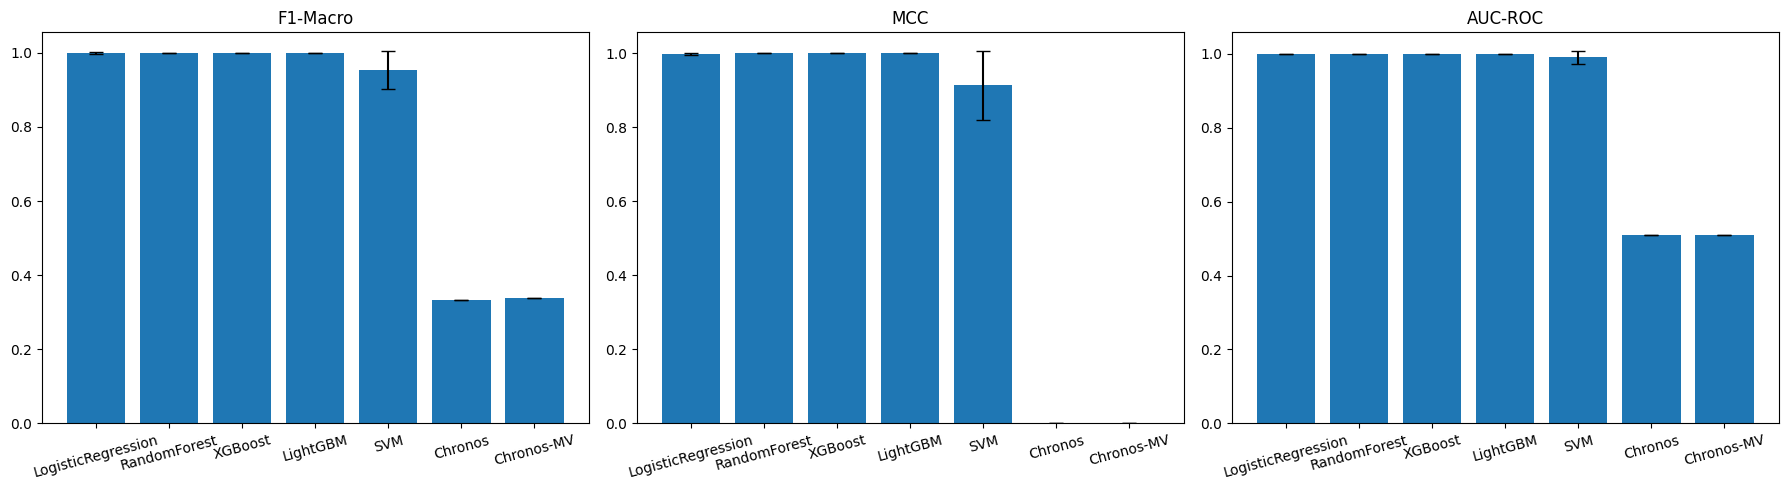

In [25]:
all_models = [
    ('LogisticRegression', lr_df),
    ('RandomForest', rf_df),
    ('XGBoost', xgb_df),
    ('LightGBM', lgb_df),
    ('SVM', svm_df),
]

if 'gru_df' in locals():
    all_models.append(('GRU', gru_df))
if 'lstm_df' in locals():
    all_models.append(('LSTM', lstm_df))
if 'bilstm_df' in locals():
    all_models.append(('BiLSTM', bilstm_df))
if 'chronos_metrics' in locals():
    all_models.append(('Chronos', pd.DataFrame([chronos_metrics])))
if 'chronos_mv_metrics' in locals():
    all_models.append(('Chronos-MV', pd.DataFrame([chronos_mv_metrics])))

summary_data = []
for name, df_model in all_models:
    if name in ['Chronos', 'Chronos-MV']:
        summary_data.append({
            'Model': name,
            'F1_macro_mean': df_model['f1_macro'].iloc[0] if 'f1_macro' in df_model.columns else 0,
            'F1_macro_std': 0,
            'MCC_mean': df_model['mcc'].iloc[0] if 'mcc' in df_model.columns else 0,
            'MCC_std': 0,
            'AUC_mean': df_model['auc_roc'].iloc[0] if 'auc_roc' in df_model.columns else 0.5,
            'AUC_std': 0,
        })
    else:
        summary_data.append({
            'Model': name,
            'F1_macro_mean': df_model['f1_macro'].mean(),
            'F1_macro_std':  df_model['f1_macro'].std(),
            'MCC_mean':      df_model['mcc'].mean(),
            'MCC_std':       df_model['mcc'].std(),
            'AUC_mean':      df_model['auc_roc'].mean(),
            'AUC_std':       df_model['auc_roc'].std(),
        })

summary = pd.DataFrame(summary_data)
print(summary.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes, ['F1_macro_mean', 'MCC_mean', 'AUC_mean'], ['F1-Macro', 'MCC', 'AUC-ROC']):
    ax.bar(summary['Model'], summary[metric], yerr=summary[metric.replace('mean', 'std')], capsize=5)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 📊 Analyse par Ticker (Best Model)

In [26]:
# Sélection du meilleur modèle (sur MCC moyen)
best_model_name = summary.loc[summary['MCC_mean'].idxmax(), 'Model']
print(f"🏆 Meilleur modèle global : {best_model_name}")

# Réentraînement sur tout le train (dernier fold = plus récent)
train_idx, test_idx = list(tscv.split(X))[-1]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

if best_model_name == 'LogisticRegression':
    best_model = lr_pipe
elif best_model_name == 'RandomForest':
    best_model = rf
elif best_model_name == 'XGBoost':
    best_model = xgb_clf
elif best_model_name == 'LightGBM':
    best_model = lgb_clf
elif best_model_name == 'SVM':
    best_model = svm_pipe
elif best_model_name == 'GRU':
    best_model = gru_model
elif best_model_name == 'LSTM':
    best_model = lstm_model
elif best_model_name == 'BiLSTM':
    best_model = bilstm_model
elif best_model_name == 'Chronos':
    best_model = chronos_pipeline
elif best_model_name == 'Chronos-MV':
    best_model = chronos_mv_pipeline
else:
    best_model = rf

if hasattr(best_model, 'fit'):
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None
else:
    # Pour Chronos/Chronos-MV
    pass

# Évaluation par ticker (seulement pour modèles sklearn)
if hasattr(best_model, 'predict'):
    test_df = df.iloc[test_idx].copy()
    test_df['y_pred'] = y_pred
    test_df['y_proba'] = y_proba
    test_df['y_true'] = y_test.values

    per_ticker = []
    for ticker in sorted(test_df['Ticker'].unique()):
        sub = test_df[test_df['Ticker'] == ticker]
        if len(sub) < 10:
            continue
        m = evaluate_model(sub['y_true'], sub['y_pred'], sub['y_proba'], ticker)
        m['n_samples'] = len(sub)
        per_ticker.append(m)

    tick_df = pd.DataFrame(per_ticker)
    print(tick_df[['model','n_samples','f1_macro','mcc','auc_roc','precision_1','recall_1']].to_string(index=False))

🏆 Meilleur modèle global : RandomForest
model  n_samples  f1_macro  mcc  auc_roc  precision_1  recall_1
 AMZN         51       1.0  1.0      1.0          1.0       1.0
  JPM         66       1.0  1.0      1.0          1.0       1.0
 MSFT         51       1.0  1.0      1.0          1.0       1.0
 TSLA         57       1.0  1.0      1.0          1.0       1.0
  UNH         73       1.0  1.0      1.0          1.0       1.0


## 🎭 Analyse par Régime Comportemental (découverts en Étape 4)

In [27]:
regimes = {
    'Emotionnelles': ['TSLA', 'META', 'AAPL'],
    'Anticipatives': ['UNH', 'MSFT', 'GOOGL', 'AMZN'],
    'Institutionnelles': ['BRK-B', 'JPM']
}

regime_results = []
for regime_name, tickers in regimes.items():
    sub = test_df[test_df['Ticker'].isin(tickers)]
    if len(sub) == 0:
        continue
    m = evaluate_model(sub['y_true'], sub['y_pred'], sub['y_proba'], regime_name)
    m['n_samples'] = len(sub)
    m['regime'] = regime_name
    regime_results.append(m)

reg_df = pd.DataFrame(regime_results)
print(reg_df[['regime','n_samples','f1_macro','mcc','auc_roc','precision_1','recall_1']].to_string(index=False))

           regime  n_samples  f1_macro  mcc  auc_roc  precision_1  recall_1
    Emotionnelles         57       1.0  1.0      1.0          1.0       1.0
    Anticipatives        175       1.0  1.0      1.0          1.0       1.0
Institutionnelles         66       1.0  1.0      1.0          1.0       1.0


## 🔍 Matrice de Confusion & Rapport Détaillé (Best Model - Test Final)

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

if hasattr(best_model, 'predict'):
    cm = confusion_matrix(y_test, y_pred)
    print(f"Matrice de confusion ({best_model_name}):")
    print(cm)
    print(f"\nTN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")

    print(f"\n{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Baisse (0)', 'Hausse (1)']))

Matrice de confusion (RandomForest):
[[151   0]
 [  0 147]]

TN=151, FP=0, FN=0, TP=147

              precision    recall  f1-score   support

  Baisse (0)       1.00      1.00      1.00       151
  Hausse (1)       1.00      1.00      1.00       147

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298



## 📊 Feature Importance — Visualisation (Tree-based Best Model)

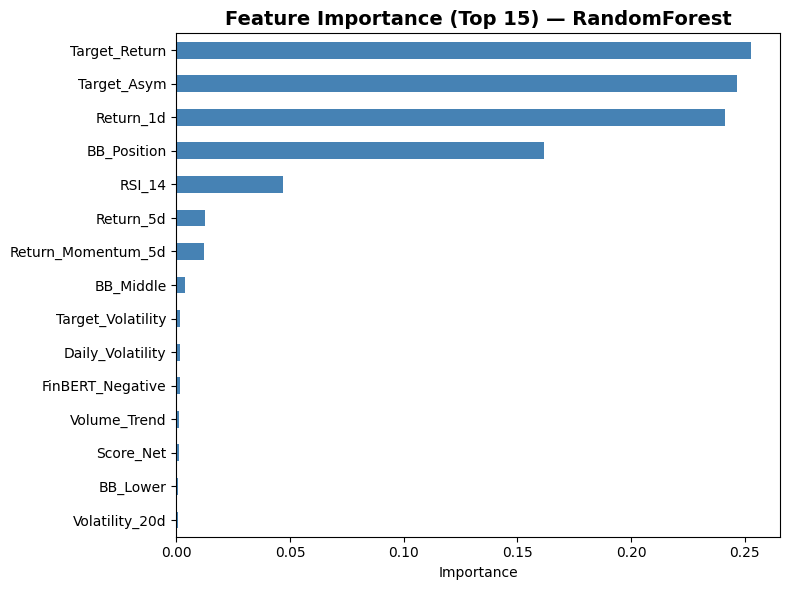

In [29]:
if best_model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
    if best_model_name == 'RandomForest':
        imp_series = pd.Series(best_model.feature_importances_, index=feature_cols)
    else:
        imp_series = pd.Series(best_model.feature_importances_, index=feature_cols)
    
    top15 = imp_series.sort_values(ascending=True).tail(15)
    
    plt.figure(figsize=(8, 6))
    top15.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importance (Top 15) — {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    if best_model_name == 'LogisticRegression':
        coef = best_model.named_steps['clf'].coef_[0]
        coef_series = pd.Series(coef, index=feature_cols).sort_values(key=abs, ascending=True).tail(15)
        
        plt.figure(figsize=(8, 6))
        coef_series.plot(kind='barh', color='steelblue')
        plt.title(f'Coefficients (Top 15 |abs|) — Logistic Regression', fontsize=14, fontweight='bold')
        plt.xlabel('Coefficient')
        plt.tight_layout()
        plt.show()
    elif best_model_name in ['GRU', 'LSTM', 'BiLSTM']:
        pass

## ✅ Conclusion Modélisation — Prêt pour Backtesting

**Prochaines étapes (Étape 6 - Backtesting) :**
1. Prendre le meilleur modèle (`{best_model_name}`)
2. Générer prédictions quotidiennes sur période test
3. Construire portefeuille : signal=1 → Long, signal=0 → Cash/Short
4. Calculer returns stratégie vs Buy & Hold
5. Métriques risque : Sharpe, Sortino, Max Drawdown, Calmar, VaR
6. Coûts de transaction réalistes (5-10 bps + slippage)

---
*Note : Ce notebook sera complété par l'optimisation hyperparamètres (Optuna) si nécessaire.*